In [25]:
# suppose I have data like B5, B6, B7, B8, B9, B10, B11, B12, B13, B14, B15, B16, B17, B18, B19, B20 , C30, D40 now this is not numerical and not categorical 

# So we split it into two parts, the first part is the letter and the second part is the number.

#Also if we have data like 7,3,1,A,B even then split it into two columns, one for the number and one for the letter.
# Write NULL in the letter column for the numerical values and NULL in the number column for the categorical values.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Mixed.csv')

df.head()


,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [26]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

<BarContainer object of 7 artists>

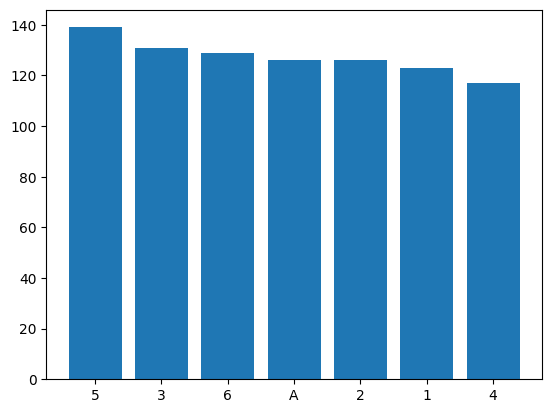

In [27]:
plt.bar(df['number'].unique(), df['number'].value_counts())

In [28]:
#extract numerical part
df['number_numerical'] =  pd.to_numeric(df["number"], errors = 'coerce', downcast = 'integer')

In [29]:
#extract categorical part
df['number_categorical'] = np.where(df['number_numerical'].isnull(), df['number'], np.nan) # jaha jaha numerical part null hai waha waha categorical part lelo otherwise null lelo


In [30]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [31]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [32]:
df['cabin_num'] = df['Cabin'].str.extract('(\d+)') # extract the numerical part from the cabin column
df['cabin_cat'] = df['Cabin'].str[0] # extract the first letter from the cabin column
df.head()

# now wherever num cabn is NAn we will put 0
df['cabin_num'] = df['cabin_num'].fillna(0)

df['cabin_cat'] = df['cabin_cat'].fillna('Unknown')
df['number_numerical'] = df['number_numerical'].fillna(0)
df['number_categorical'] = df['number_categorical'].fillna('Unknown')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\gurpr\AppData\Local\Temp\ipykernel_21380\2884154714.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['cabin_num'] = df['Cabin'].str.extract('(\d+)') # extract the numerical part from the cabin column


,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,Unknown,0,Unknown
1,C85,PC 17599,3,1,3.0,Unknown,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,Unknown,0,Unknown
3,C123,113803,3,1,3.0,Unknown,123,C
4,NaN,373450,A,0,0.0,A,0,Unknown


<Axes: xlabel='cabin_cat'>

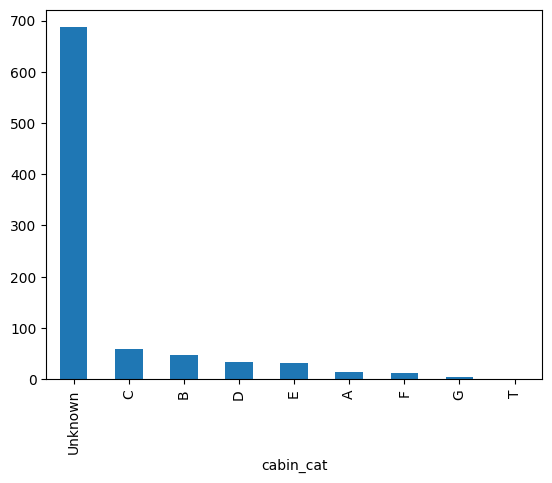

In [35]:
df['cabin_cat'].value_counts().plot(kind='bar')

In [37]:
df['ticket_num'] = df['Ticket'].apply(lambda s : s.split()[-1]) # split the ticket column by space and take the last part as the ticket number
# if ticket is A/5 2171 it splits it into 2 - A5 and 2171 and 2171is taken to numeric
df['ticket_num'] = pd.to_numeric(df['ticket_num'], errors = 'coerce', downcast= 'integer')

df['ticket_cat'] = df['Ticket'].apply(lambda s : s.split()[0])
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan, df['ticket_cat'])
# np.where(condition, value_if_true, value_if_false)
# The Condition (df['ticket_cat'].str.isdigit()): This checks if the extracted string consists only of numbers.

# Value if True (np.nan): If the string is just a number (like "113803"), it means there was no prefix. The code replaces these with NaN (null) because a number is not a category.

# Value if False (df['ticket_cat']): If the string contains letters (like "A/5"), it keeps the value exactly as it is.


In [38]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,Unknown,0,Unknown,21171.0,A/5
1,C85,PC 17599,3,1,3.0,Unknown,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,Unknown,0,Unknown,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,Unknown,123,C,113803.0,NaN
4,NaN,373450,A,0,0.0,A,0,Unknown,373450.0,NaN
